 # DATA LOADING AND CLEANING

# 1. Import Libraries


In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

# 2. Load Datasets

In [35]:
reuse = pd.read_excel("Furniture Reuse List.xlsx")

disposal = pd.read_excel("Disposal Cost  List.xlsx")

repurchase = pd.read_excel("Repurchase Cost List.xlsx")

# 3. Initial Data Exploration

In [36]:
# Check Data Dimension
datasets = {"Reuse": reuse, "Disposal": disposal, "Repurchase": repurchase}
for name, df in datasets.items():
    print(f"{name} Dataset:", df.shape)

Reuse Dataset: (742, 9)
Disposal Dataset: (61, 8)
Repurchase Dataset: (88, 5)


In [37]:
# View first five row
print("Reuse Dataset")
display(reuse.head())

print("Disposal Dataset")
display(disposal.head())

print("Repurchase Dataset")
display(repurchase.head())


Reuse Dataset


,Date,Type of Item,Location,Condition,Category,Quantity,Ave Cost (£),Ave Weight ( KG),Ave CO2 (KG)
0,2021-06-16 00:00:00,Desk,Greenwich,Excellent,Office,2.0,2,60,104
1,2021-06-16 00:00:00,Pedestal,Greenwich,Good,Storage,1.0,50,14,26
2,2021-06-16 00:00:00,Bookcase,Greenwich,Good,Storage,1.0,134,12,69.55
3,2021-06-16 00:00:00,Desk Divider,Greenwich,Good,Office,1.0,50,20,24
4,2021-06-16 00:00:00,Desk Divider,Greenwich,Good,Office,2.0,20,10,48


Disposal Dataset


,Date,Furniture Description,Location,Category,Quantity,Estimated value (£),Estimated Waste (KG)\n,Estimated CO2 emissions (KG)
0,2021-11-11 00:00:00,Coffee table,Greenwich,Table,3,120.0,30.0,62.40
1,2021-11-11 00:00:00,Static chair,Greenwich,seating,1,20.0,7.0,10.40
2,2021-11-11 00:00:00,Pedestal,Greenwich,storage,2,100.0,28.0,52.00
3,2021-11-11 00:00:00,Filing cabinet,Greenwich,storage,1,100.0,30.0,52.00
4,2021-11-11 00:00:00,Operator chair,Greenwich,seating,6,642.0,72.0,333.84


Repurchase Dataset


,Category,Item,Ave. Cost (£),Ave. Weight (KG),Ave. CO2 (KG)
0,Seating,Armchair,236.785714,15.00,72.930000
1,Seating,Chair,89.714286,19.55,27.632000
2,Seating,Bench Seat,149.300000,26.25,45.984400
3,Seating,Sofa,248.600000,45.00,76.568800
4,Seating,Sofa,363.833333,68.00,112.060667


In [38]:
# Dataset Information
for name, df in datasets.items():
    print(f"{name} Dataset:", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              733 non-null    object 
 1   Type of Item      742 non-null    str    
 2   Location          742 non-null    str    
 3   Condition         698 non-null    str    
 4   Category          742 non-null    str    
 5   Quantity          740 non-null    float64
 6   Ave Cost (£)      584 non-null    object 
 7   Ave Weight ( KG)  591 non-null    object 
 8   Ave CO2 (KG)      583 non-null    object 
dtypes: float64(1), object(4), str(4)
memory usage: 75.2+ KB
Reuse Dataset: None
<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          61 non-null     object 
 1   Furniture Description         61 non

# 4. Rename Variables


In [39]:
# Print column
for name, df in datasets.items():
    print(f"{name} Dataset:", df.columns)

Reuse Dataset: Index(['Date', 'Type of Item', 'Location ', 'Condition', 'Category',
       'Quantity', 'Ave Cost (£)', 'Ave Weight ( KG)', 'Ave CO2 (KG)'],
      dtype='str')
Disposal Dataset: Index(['Date', 'Furniture Description', 'Location', 'Category', 'Quantity',
       'Estimated value (£) ', 'Estimated Waste (KG)\n',
       'Estimated CO2 emissions (KG)'],
      dtype='str')
Repurchase Dataset: Index(['Category', 'Item', 'Ave. Cost (£)', 'Ave. Weight (KG)',
       'Ave. CO2 (KG)'],
      dtype='str')


In [40]:
# Rename Column
reuse.columns = ['Date','Item','Campus','Condition','Category','Quantity','Cost','Weight','CO2']
disposal.columns = ['Date','Item','Campus','Category','Quantity','Cost','Weight','CO2']
repurchase.columns = ['Category','Item','Cost','Weight','CO2']

In [41]:
for name, df in datasets.items():
    print(f"{name} Dataset:", df.columns)

Reuse Dataset: Index(['Date', 'Item', 'Campus', 'Condition', 'Category', 'Quantity', 'Cost',
       'Weight', 'CO2'],
      dtype='str')
Disposal Dataset: Index(['Date', 'Item', 'Campus', 'Category', 'Quantity', 'Cost', 'Weight',
       'CO2'],
      dtype='str')
Repurchase Dataset: Index(['Category', 'Item', 'Cost', 'Weight', 'CO2'], dtype='str')


# 5. Convert Data Types


In [42]:
# ==========================================
# COMPREHENSIVE COST COLUMN AUDIT
# ==========================================

print("=" * 60)
print("COMPREHENSIVE COST COLUMN AUDIT")
print("=" * 60)

all_issues = {}

for name, df in [("Reuse", reuse), ("Disposal", disposal), ("Repurchase", repurchase)]:
    print(f"\n{name} Dataset:")
    print("-" * 40)
    
    # 1. Data type
    dtype = df['Cost'].dtype
    print(f"1. Data type: {dtype}")
    
    # 2. Null count
    null_count = df['Cost'].isna().sum()
    print(f"2. Null values: {null_count}")
    
    # 3. Check for formatting characters
    cost_str = df['Cost'].astype(str)
    has_pound = cost_str.str.contains('£', regex=False).sum()
    has_comma = cost_str.str.contains(',', regex=False).sum()
    has_spaces = cost_str.str.contains(' ', regex=False).sum()
    
    print(f"3. Formatting issues:")
    print(f"   - Contains '£': {has_pound} rows")
    print(f"   - Contains ',': {has_comma} rows")
    print(f"   - Contains spaces: {has_spaces} rows")
    
    # 4. Show problematic rows if any
    if has_pound > 0 or has_comma > 0 or has_spaces > 0:
        print("\n4. Sample problematic values:")
        problematic = df[cost_str.str.contains('£|,| ', regex=True, na=False)]
        print(problematic['Cost'].head(10).tolist())
        
        # Store for summary
        all_issues[name] = {
            'has_pound': has_pound,
            'has_comma': has_comma,
            'has_spaces': has_spaces,
            'sample': problematic['Cost'].head(3).tolist()
        }
    else:
        print("\n4. ✓ No formatting issues detected")
        
    # 5. Check if conversion to numeric would work
    print(f"\n5. Can convert to numeric?")
    try:
        test = pd.to_numeric(df['Cost'], errors='raise')
        print("   ✓ All values are numeric-compatible")
    except:
        print("   ✗ Some values cannot be converted to numeric")
        non_numeric = df[~df['Cost'].astype(str).str.replace('.', '', regex=False).str.isdigit()]
        print(f"   Non-numeric values found: {non_numeric['Cost'].head(5).tolist()}")
    
    print("=" * 40)

# Summary
print("\n" + "=" * 60)
print("SUMMARY OF COST FORMATTING ISSUES")
print("=" * 60)
if all_issues:
    for name, issues in all_issues.items():
        print(f"\n{name}:")
        print(f"  - £ symbols: {issues['has_pound']}")
        print(f"  - Commas: {issues['has_comma']}")
        print(f"  - Spaces: {issues['has_spaces']}")
        print(f"  - Sample: {issues['sample']}")
else:
    print("\n✓ No formatting issues found in any dataset")

COMPREHENSIVE COST COLUMN AUDIT

Reuse Dataset:
----------------------------------------
1. Data type: object
2. Null values: 158
3. Formatting issues:
   - Contains '£': 4 rows
   - Contains ',': 0 rows
   - Contains spaces: 0 rows

4. Sample problematic values:
['£250', '£100', '£100', '£100']

5. Can convert to numeric?
   ✗ Some values cannot be converted to numeric
   Non-numeric values found: ['£250', '£100', '£100', '£100', nan]

Disposal Dataset:
----------------------------------------
1. Data type: float64
2. Null values: 0
3. Formatting issues:
   - Contains '£': 0 rows
   - Contains ',': 0 rows
   - Contains spaces: 0 rows

4. ✓ No formatting issues detected

5. Can convert to numeric?
   ✓ All values are numeric-compatible

Repurchase Dataset:
----------------------------------------
1. Data type: float64
2. Null values: 0
3. Formatting issues:
   - Contains '£': 0 rows
   - Contains ',': 0 rows
   - Contains spaces: 0 rows

4. ✓ No formatting issues detected

5. Can conve

In [43]:
# Convert date
reuse["Date"] = pd.to_datetime(reuse["Date"], errors="coerce", dayfirst=True)

disposal["Date"] = pd.to_datetime(disposal["Date"], errors="coerce", dayfirst=True)

# Clean Cost and CO2 
reuse["Cost"] = (reuse["Cost"].astype(str).str.replace("£", "", regex=False).str.replace(",", "", regex=False).str.strip())

reuse["CO2"] = ( reuse["CO2"].astype(str).str.replace("222..56", "222.56", regex=False).replace("?", np.nan))

# Convert to numeric column
reuse["Cost"] = pd.to_numeric(reuse["Cost"], errors="coerce")

reuse["Weight"] = pd.to_numeric(reuse["Weight"], errors="coerce")

reuse["CO2"] = pd.to_numeric(reuse["CO2"], errors="coerce")

In [44]:
# Rounded numeric values
datasets = {"Reuse": reuse, "Disposal": disposal, "Repurchase": repurchase}

for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].round(2)

#verify result
for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print(df.head())


Reuse Dataset
        Date          Item     Campus  Condition  Category  Quantity   Cost  \
0 2021-06-16          Desk  Greenwich  Excellent    Office       2.0    2.0   
1 2021-06-16      Pedestal  Greenwich       Good  Storage        1.0   50.0   
2 2021-06-16     Bookcase   Greenwich       Good  Storage        1.0  134.0   
3 2021-06-16  Desk Divider  Greenwich       Good    Office       1.0   50.0   
4 2021-06-16  Desk Divider  Greenwich       Good    Office       2.0   20.0   

   Weight     CO2  
0    60.0  104.00  
1    14.0   26.00  
2    12.0   69.55  
3    20.0   24.00  
4    10.0   48.00  

Disposal Dataset
        Date            Item     Campus Category  Quantity   Cost  Weight  \
0 2021-11-11    Coffee table  Greenwich    Table         3  120.0    30.0   
1 2021-11-11    Static chair  Greenwich  seating         1   20.0     7.0   
2 2021-11-11        Pedestal  Greenwich  storage         2  100.0    28.0   
3 2021-11-11  Filing cabinet  Greenwich  storage         1  100.

In [45]:
# Check info again
datasets = {"Reuse": reuse, "Disposal": disposal, "Repurchase": repurchase}
for name, df in datasets.items():
    print(f"{name} Dataset:", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       733 non-null    datetime64[ns]
 1   Item       742 non-null    str           
 2   Campus     742 non-null    str           
 3   Condition  698 non-null    str           
 4   Category   742 non-null    str           
 5   Quantity   740 non-null    float64       
 6   Cost       584 non-null    float64       
 7   Weight     584 non-null    float64       
 8   CO2        582 non-null    float64       
dtypes: datetime64[ns](1), float64(4), str(4)
memory usage: 75.2 KB
Reuse Dataset: None
<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      61 non-null     datetime64[us]
 1   Item      61 non-null     str           
 2   Campus    61 non-null 

# 6. Statistical Summary

In [46]:
# description excluding date 
for name, df in datasets.items():
    print(f"\n{name} Dataset")
    display(df.select_dtypes(include=["number"]).describe().T)


Reuse Dataset


,count,mean,std,min,25%,50%,75%,max
Quantity,740.0,3.866216,10.326979,1.0,1.0,1.00,3.000,150.0
Cost,584.0,374.758339,1044.579167,2.0,100.0,149.50,300.000,16800.0
Weight,584.0,56.103955,128.016610,1.0,14.7,25.00,50.000,1920.0
CO2,582.0,139.538110,319.479741,8.5,36.4,55.64,111.745,4411.2



Disposal Dataset


,count,mean,std,min,25%,50%,75%,max
Quantity,61.0,7.704918,10.218193,1.0,1.00,4.0,10.00,50.0
Cost,61.0,744.551311,896.149952,20.0,126.00,428.0,963.00,4200.0
Weight,61.0,144.254098,238.973127,7.0,30.00,70.0,150.00,1260.0
CO2,61.0,301.451475,415.110384,10.4,55.64,156.0,333.84,2184.0



Repurchase Dataset


,count,mean,std,min,25%,50%,75%,max
Cost,88.0,123.834318,95.198885,1.29,62.7075,100.0,163.5975,465.30
Weight,88.0,19.612955,18.538500,0.10,7.1650,14.0,25.0000,90.00
CO2,88.0,38.140909,29.320568,0.40,19.3125,30.8,50.3850,143.31


# 7. Outlier Detection

Outlier detection was performed on the numerical variables within each dataset to identify unusually high or low observations that may influence subsequent analysis. Boxplots and the Interquartile Range (IQR) method were used to identify potential outliers.

Outliers were examined to determine whether they represented genuine observations or potential data entry errors. As the datasets describe real furniture transactions, identified outliers were retained where they reflected legitimate variation in furniture characteristics rather than erroneous records.

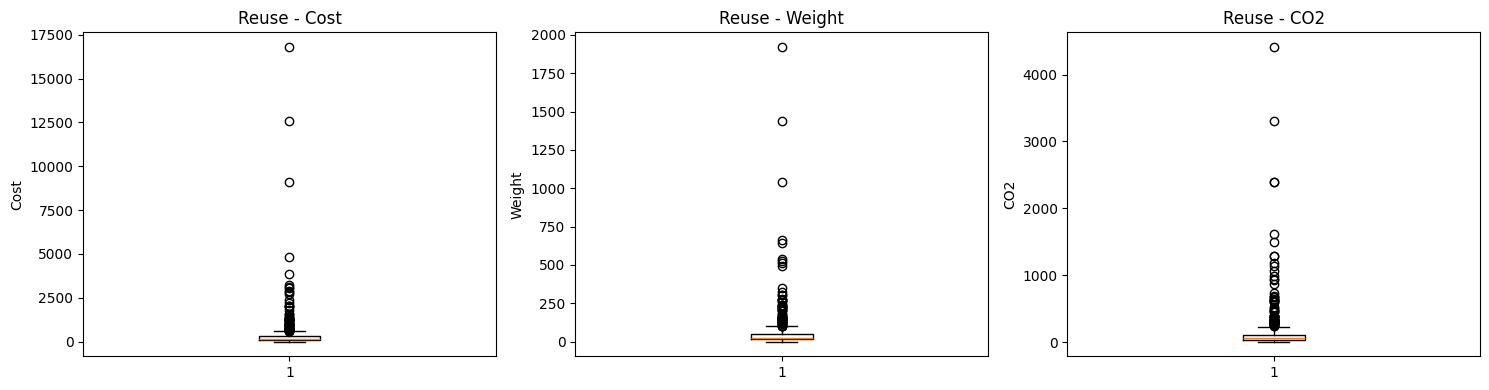

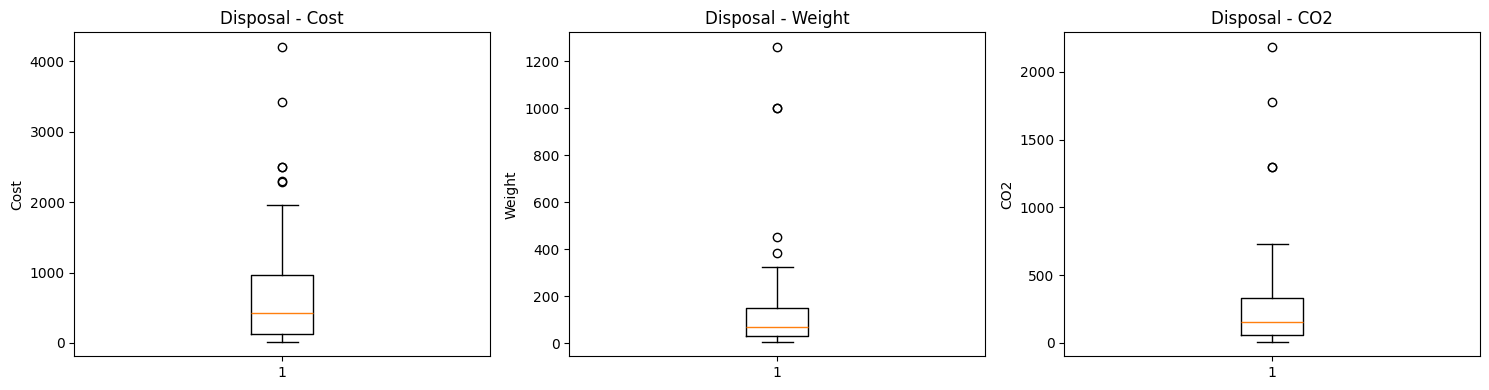

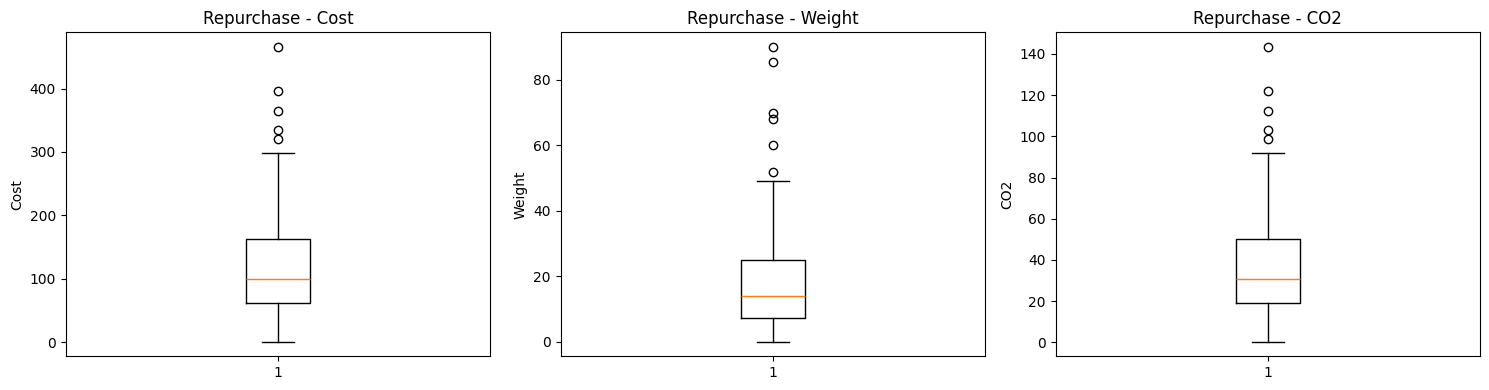

In [47]:
# ==========================================
# OUTLIER DETECTION USING BOXPLOTS
# ==========================================

import matplotlib.pyplot as plt

datasets = {
    "Reuse": reuse,
    "Disposal": disposal,
    "Repurchase": repurchase
}

numeric_columns = ["Cost", "Weight", "CO2"]

for dataset_name, df in datasets.items():

    available_cols = [col for col in numeric_columns if col in df.columns]

    if not available_cols:
        continue

    fig, axes = plt.subplots(1, len(available_cols),
                             figsize=(5*len(available_cols),4))

    if len(available_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, available_cols):
        ax.boxplot(df[col].dropna())
        ax.set_title(f"{dataset_name} - {col}")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [48]:
# ==========================================
# OUTLIER DETECTION USING IQR
# ==========================================

def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return lower_bound, upper_bound, len(outliers)


for dataset_name, df in datasets.items():

    print("="*60)
    print(dataset_name.upper())
    print("="*60)

    for col in numeric_columns:

        if col in df.columns:

            lower, upper, n_outliers = detect_outliers_iqr(df, col)

            print(f"{col}")
            print(f"  Lower Bound : {lower:.2f}")
            print(f"  Upper Bound : {upper:.2f}")
            print(f"  Outliers    : {n_outliers}")
            print()

REUSE
Cost
  Lower Bound : -200.00
  Upper Bound : 600.00
  Outliers    : 70

Weight
  Lower Bound : -38.25
  Upper Bound : 102.95
  Outliers    : 58

CO2
  Lower Bound : -76.62
  Upper Bound : 224.76
  Outliers    : 70

DISPOSAL
Cost
  Lower Bound : -1129.50
  Upper Bound : 2218.50
  Outliers    : 6

Weight
  Lower Bound : -150.00
  Upper Bound : 330.00
  Outliers    : 5

CO2
  Lower Bound : -361.66
  Upper Bound : 751.14
  Outliers    : 4

REPURCHASE
Cost
  Lower Bound : -88.63
  Upper Bound : 314.93
  Outliers    : 5

Weight
  Lower Bound : -19.59
  Upper Bound : 51.75
  Outliers    : 6

CO2
  Lower Bound : -27.30
  Upper Bound : 96.99
  Outliers    : 5



# Interpretation

The boxplots and IQR analysis identified several observations outside the expected range for numerical variables. These records were manually reviewed and determined to represent genuine variations in furniture characteristics, such as high-value items, heavier furniture, or unusually low-cost items, rather than data entry errors.

Consequently, no outlier treatment (e.g., removal or winsorisation) was applied. Retaining these observations preserves the integrity of the original data and ensures that subsequent analyses accurately reflect real-world furniture transactions.

# 8. Missing Value Analysis

In [49]:
for name, df in datasets.items():
    print(f"{name} Dataset:", df.isnull().sum())

Reuse Dataset: Date           9
Item           0
Campus         0
Condition     44
Category       0
Quantity       2
Cost         158
Weight       158
CO2          160
dtype: int64
Disposal Dataset: Date        0
Item        0
Campus      0
Category    0
Quantity    0
Cost        0
Weight      0
CO2         0
dtype: int64
Repurchase Dataset: Category    0
Item        0
Cost        0
Weight      0
CO2         0
dtype: int64


# 9. Category Standardisation

In [50]:
# Check Category
for name, df in [("Reuse", reuse), ("Disposal", disposal), ("Repurchase", repurchase)]:
    print(f"{name}: {sorted(df['Category'].dropna().unique())}")

Reuse: ['Cafe/Kitchen', 'Desk', 'Halls', 'Medical', 'Office', 'Seating', 'Stationery', 'Storage', 'Storage ', 'Tables', 'chairs', 'office', 'seating', 'storage', 'storage ', 'tables']
Disposal: ['Desks', 'Table', 'chairs', 'desks', 'office', 'seating', 'storage', 'table']
Repurchase: ['Halls', 'Medical', 'Office', 'Seating', 'Stationery', 'Storage', 'Table']


In [51]:
category_mapping = {
    # Correct category names
    "office": "Office",
    "storage": "Storage",
    "seating": "Seating",
    "Tables": "Table",
    "table": "Table",
    "tables": "Table",

    # Data entry mistakes in the Category column
    "desk": "Office",
    "desks": "Office",
    "chair": "Seating",
    "chairs": "Seating"
}

for df in [reuse, disposal, repurchase]:
    df["Category"] = (
        df["Category"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(category_mapping)
    )

In [52]:
# Check the result 
for name, df in {
    "Reuse": reuse,
    "Disposal": disposal,
    "Repurchase": repurchase
}.items():
    print(f"\n{name} Categories:")
    print(sorted(df["Category"].dropna().unique()))


Reuse Categories:
['Office', 'Seating', 'Storage', 'Table', 'cafe/kitchen', 'halls', 'medical', 'stationery']

Disposal Categories:
['Office', 'Seating', 'Storage', 'Table']

Repurchase Categories:
['Office', 'Seating', 'Storage', 'Table', 'halls', 'medical', 'stationery']


In [53]:
# Removing unwanted categories
# Removing the other categories 
keep_categories = ["Office", "Seating", "Storage", "Table"]

reuse = reuse[reuse["Category"].isin(keep_categories)]
disposal = disposal[disposal["Category"].isin(keep_categories)]
repurchase = repurchase[repurchase["Category"].isin(keep_categories)]

In [54]:
# Remaining Categories we are going to use
for name, df in {
    "Reuse": reuse,
    "Disposal": disposal,
    "Repurchase": repurchase
}.items():
    print(f"\n{name} Categories:")
    print(sorted(df["Category"].dropna().unique()))


Reuse Categories:
['Office', 'Seating', 'Storage', 'Table']

Disposal Categories:
['Office', 'Seating', 'Storage', 'Table']

Repurchase Categories:
['Office', 'Seating', 'Storage', 'Table']


# 10. Condition Standardisation 
On the basis of its quality difference there is not much more difference so standarised in 3 types.

In [55]:
# CHECK the codition details
print(reuse["Condition"].value_counts(dropna=False))

Condition
Excellent         419
Good              185
excellent          37
NaN                37
Fair                6
good                4
Fair (stained)      4
Good                3
Excellent           2
fair                1
Good as New         1
Good as new         1
Name: count, dtype: int64


In [56]:
# Standardize Condition column
reuse['Condition'] = reuse['Condition'].str.strip().str.title()

condition_mapping = {
    'Excellent ': 'Excellent',
    'excellent': 'Excellent',
    'good': 'Good',
    'Good As New': 'Good',
    'Fair (Stained)': 'Fair',
    'Good as new': 'Good'
}

reuse['Condition'] = reuse['Condition'].replace(condition_mapping)
# Check categories
print(reuse['Condition'].value_counts(dropna=False))


Condition
Excellent    458
Good         194
NaN           37
Fair          11
Name: count, dtype: int64


# 11. Campus Standardisation 


In [57]:
# Verifying campus categories
for name, df in [("Reuse", reuse), ("Disposal", disposal)]:
    print(f"{name} Campus:")
    print(df["Campus"].unique())
    print()

Reuse Campus:
<ArrowStringArray>
['Greenwich', 'Avery Hill', 'Greenwich ', 'Medway', 'greenwich']
Length: 5, dtype: str

Disposal Campus:
<ArrowStringArray>
['Greenwich', 'Avery Hill', 'Medway']
Length: 3, dtype: str



In [58]:
# Standardisation 
reuse["Campus"] = reuse["Campus"].astype(str).str.strip().str.title()

In [59]:
# Check
reuse["Campus"].unique()


<ArrowStringArray>
['Greenwich', 'Avery Hill', 'Medway']
Length: 3, dtype: str

# 12. Missing Value Imputation

In [60]:
# Filling missing values in furniture reuse list 
# Date
reuse['Date'] = pd.to_datetime(reuse['Date'], errors='coerce')
reuse['Date'] = reuse['Date'].ffill()

# Condition
reuse['Condition'] = reuse['Condition'].fillna(reuse['Condition'].mode()[0])

# Quantity
reuse['Quantity'] = reuse['Quantity'].fillna(reuse['Quantity'].median())

# Numeric columns (Here we have used category-wise median to fill to make the result more realistic)
num_cols = ['Cost', 'Weight', 'CO2']
for col in num_cols:
    reuse[col] = pd.to_numeric(reuse[col], errors='coerce')
    reuse[col] = reuse.groupby('Item')[col].transform(
        lambda x: x.fillna(x.median())
    )
    reuse[col] = reuse[col].fillna(reuse[col].median())

In [61]:
# Again, check missing values 
print("Reuse Dataset")
display(reuse.isnull().sum())

print("Disposal Dataset")
display(disposal.isnull().sum())

print("Repurchase Dataset")
display(repurchase.isnull().sum())

Reuse Dataset


Date         0
Item         0
Campus       0
Condition    0
Category     0
Quantity     0
Cost         0
Weight       0
CO2          0
dtype: int64

Disposal Dataset


Date        0
Item        0
Campus      0
Category    0
Quantity    0
Cost        0
Weight      0
CO2         0
dtype: int64

Repurchase Dataset


Category    0
Item        0
Cost        0
Weight      0
CO2         0
dtype: int64

# 13. Data Validation  

Following the missing value imputation process, validation checks were performed to ensure that the cleaned datasets satisfied expected business rules. The checks verified that numerical variables contained no invalid negative values and that the cleaned datasets were free from missing values in key variables required for subsequent analysis.

In [62]:
print("=" * 80)
print("DATA VALIDATION")
print("=" * 80)

datasets = {
    "Reuse": reuse,
    "Disposal": disposal,
    "Repurchase": repurchase
}

for name, df in datasets.items():

    print(f"\n{name} Dataset")
    print("-" * 50)

 # Missing Values
    
    missing = df.isnull().sum().sum()

    if missing == 0:
        print("✓ No missing values remaining.")
    else:
        print(f"⚠ {missing} missing values remain.")

# Negative Values
   
    for col in ["Cost", "Weight", "CO2", "Quantity"]:

        if col in df.columns:

            negative = (df[col] < 0).sum()

            if negative == 0:
                print(f"✓ {col}: No negative values.")
            else:
                print(f"⚠ {col}: {negative} negative values detected.")


# Date Validation

    if "Date" in df.columns:

        invalid_dates = df["Date"].isna().sum()

        if invalid_dates == 0:
            print("✓ All dates are valid.")
        else:
            print(f"⚠ {invalid_dates} invalid dates found.")

print("\nValidation completed.")

DATA VALIDATION

Reuse Dataset
--------------------------------------------------
✓ No missing values remaining.
✓ Cost: No negative values.
✓ Weight: No negative values.
✓ CO2: No negative values.
✓ Quantity: No negative values.
✓ All dates are valid.

Disposal Dataset
--------------------------------------------------
✓ No missing values remaining.
✓ Cost: No negative values.
✓ Weight: No negative values.
✓ CO2: No negative values.
✓ Quantity: No negative values.
✓ All dates are valid.

Repurchase Dataset
--------------------------------------------------
✓ No missing values remaining.
✓ Cost: No negative values.
✓ Weight: No negative values.
✓ CO2: No negative values.

Validation completed.


### Interpretation

The validation checks confirmed that the cleaned datasets contained no remaining missing values in the key variables used for analysis. Furthermore, all numerical variables satisfied the expected business rules by containing no negative values, while the date variables were successfully converted into valid datetime format. These checks provide confidence that the datasets are suitable for subsequent exploratory analysis and predictive modelling.

 # 14.Check Duplicates

In [63]:
for name, df in datasets.items():
    print(f"{name} Dataset:", df.duplicated().sum())

Reuse Dataset: 131
Disposal Dataset: 0
Repurchase Dataset: 0


The dataset was examined for duplicate records. Although 131 duplicate rows were identified based on identical attribute values, they were retained because the dataset represents real-world furniture reuse transactions, where multiple identical items may legitimately be recorded. Without a unique transaction identifier, these records could not be confidently classified as data entry errors.



In [64]:
for name, df in datasets.items():
    print(f"{name} Dataset:", df.info())

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 741
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       700 non-null    datetime64[ns]
 1   Item       700 non-null    str           
 2   Campus     700 non-null    str           
 3   Condition  700 non-null    str           
 4   Category   700 non-null    str           
 5   Quantity   700 non-null    float64       
 6   Cost       700 non-null    float64       
 7   Weight     700 non-null    float64       
 8   CO2        700 non-null    float64       
dtypes: datetime64[ns](1), float64(4), str(4)
memory usage: 76.5 KB
Reuse Dataset: None
<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      61 non-null     datetime64[us]
 1   Item      61 non-null     str           
 2   Campus    61 non-null     s

# 15. Final Data Quality Report

A final data quality assessment was conducted after completing all preprocessing steps. The purpose of this assessment was to confirm that the datasets were complete, internally consistent and suitable for subsequent exploratory data analysis and predictive modelling.

The report summarises the key quality indicators for each cleaned dataset, including dataset dimensions, missing values, duplicate records and memory usage.

In [65]:
print("=" * 80)
print("FINAL DATA QUALITY REPORT")
print("=" * 80)

datasets = {
    "Reuse": reuse,
    "Disposal": disposal,
    "Repurchase": repurchase
}

summary = []

for name, df in datasets.items():

    # Basic information
    rows = len(df)
    columns = len(df.columns)
    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    memory = round(df.memory_usage(deep=True).sum() / 1024, 2)

    # Category information
    categories = df["Category"].nunique() if "Category" in df.columns else "N/A"

    # Item information
    items = df["Item"].nunique() if "Item" in df.columns else "N/A"

    summary.append({
        "Dataset": name,
        "Rows": rows,
        "Columns": columns,
        "Missing Values": missing,
        "Duplicate Records": duplicates,
        "Unique Categories": categories,
        "Unique Items": items,
        "Memory Usage (KB)": memory
    })

# Create summary table
summary_df = pd.DataFrame(summary)
summary_df.style.hide(axis="index")

FINAL DATA QUALITY REPORT


Dataset,Rows,Columns,Missing Values,Duplicate Records,Unique Categories,Unique Items,Memory Usage (KB)
Reuse,700,9,0,131,4,43,76.480000
Disposal,61,8,0,0,4,21,5.560000
Repurchase,69,5,0,0,4,24,4.280000


### Interpretation

The final data quality assessment confirms that the three datasets have been successfully cleaned and standardised. All missing values have been appropriately addressed, category labels have been standardised, and data types have been converted into suitable formats.

The Reuse dataset contains duplicate records; however, these were intentionally retained as they represent genuine repeated furniture transactions rather than data entry errors.

Overall, the cleaned datasets are complete, internally consistent, and satisfy the defined validation criteria. They are therefore considered suitable for subsequent exploratory data analysis, statistical modelling, and machine learning.

# 16. Save Cleaned Data

In [66]:

# In CSV
reuse.to_csv("Reuse_Clean.csv", index=False)
disposal.to_csv("Disposal_Clean.csv", index=False)
repurchase.to_csv("Repurchase_Clean.csv", index=False)

# In Excel
reuse.to_excel("Reuse_Clean.xlsx", index=False)
disposal.to_excel("Disposal_Clean.xlsx", index=False)
repurchase.to_excel("Repurchase_Clean.xlsx", index=False)


# 17. Data Cleaning Summary

The data cleaning process was undertaken to improve the quality, consistency and reliability of the furniture datasets prior to exploratory data analysis and predictive modelling. The preprocessing workflow ensured that the datasets were complete, standardised and suitable for subsequent analysis.

The following data cleaning tasks were completed:

- Imported and inspected the three datasets (Reuse, Disposal and Repurchase).
- Renamed variables to establish a consistent naming convention across datasets.
- Converted date variables to the appropriate datetime format.
- Converted numerical variables (Cost, Weight and CO₂) into numeric data types by removing formatting inconsistencies.
- Generated descriptive statistics to understand the distribution of numerical variables.
- Performed outlier detection using boxplots and the Interquartile Range (IQR) method. Identified outliers were retained because they represented genuine furniture characteristics rather than data entry errors.
- Assessed missing values and applied appropriate imputation techniques, including forward filling dates, mode imputation for categorical variables, median imputation for numerical variables and category-wise median imputation where appropriate.
- Standardised furniture categories and condition labels to ensure consistency across datasets.
- Removed irrelevant furniture categories that were outside the scope of the analysis.
- Validated the cleaned datasets by checking for remaining missing values, invalid numerical values and successful date conversions.
- Investigated duplicate records and retained legitimate repeated observations that represented actual furniture transactions.
- Performed a final data quality assessment to verify dataset completeness, consistency and readiness for analysis.
- Exported the cleaned datasets in both CSV and Excel formats for subsequent exploratory analysis and predictive modelling.

Overall, the data cleaning process produced high-quality datasets with consistent variable names, standardised categories, valid data types and minimal data quality issues. These datasets provide a reliable foundation for the subsequent stages of exploratory data analysis, statistical modelling and machine learning.